# Model Analysis Notebook

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import mplhep as hep
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.style.use(hep.style.ATLAS)

sys.path.append(os.path.abspath(".."))
from ringer_zero.models.vkan import select_models, model_inference  # noqa: E402

%matplotlib inline

In [2]:
ET_COL = "TrigEMClusterContainer.et"
ETA_COL = "TrigEMClusterContainer.eta"
RINGS_COL = "TrigEMClusterContainer.ringsE"
FOLD_COL = "kfold"
LABEL_COL = "label"
DATA_TABLE = "electron_ringer.parquet"
KFOLD_TABLE = "standard_binning_kfold.parquet"

model_path = Path("../results/vkan")
dataset_dir = Path("../../data/mc21_isabela_qt_no_restriction")

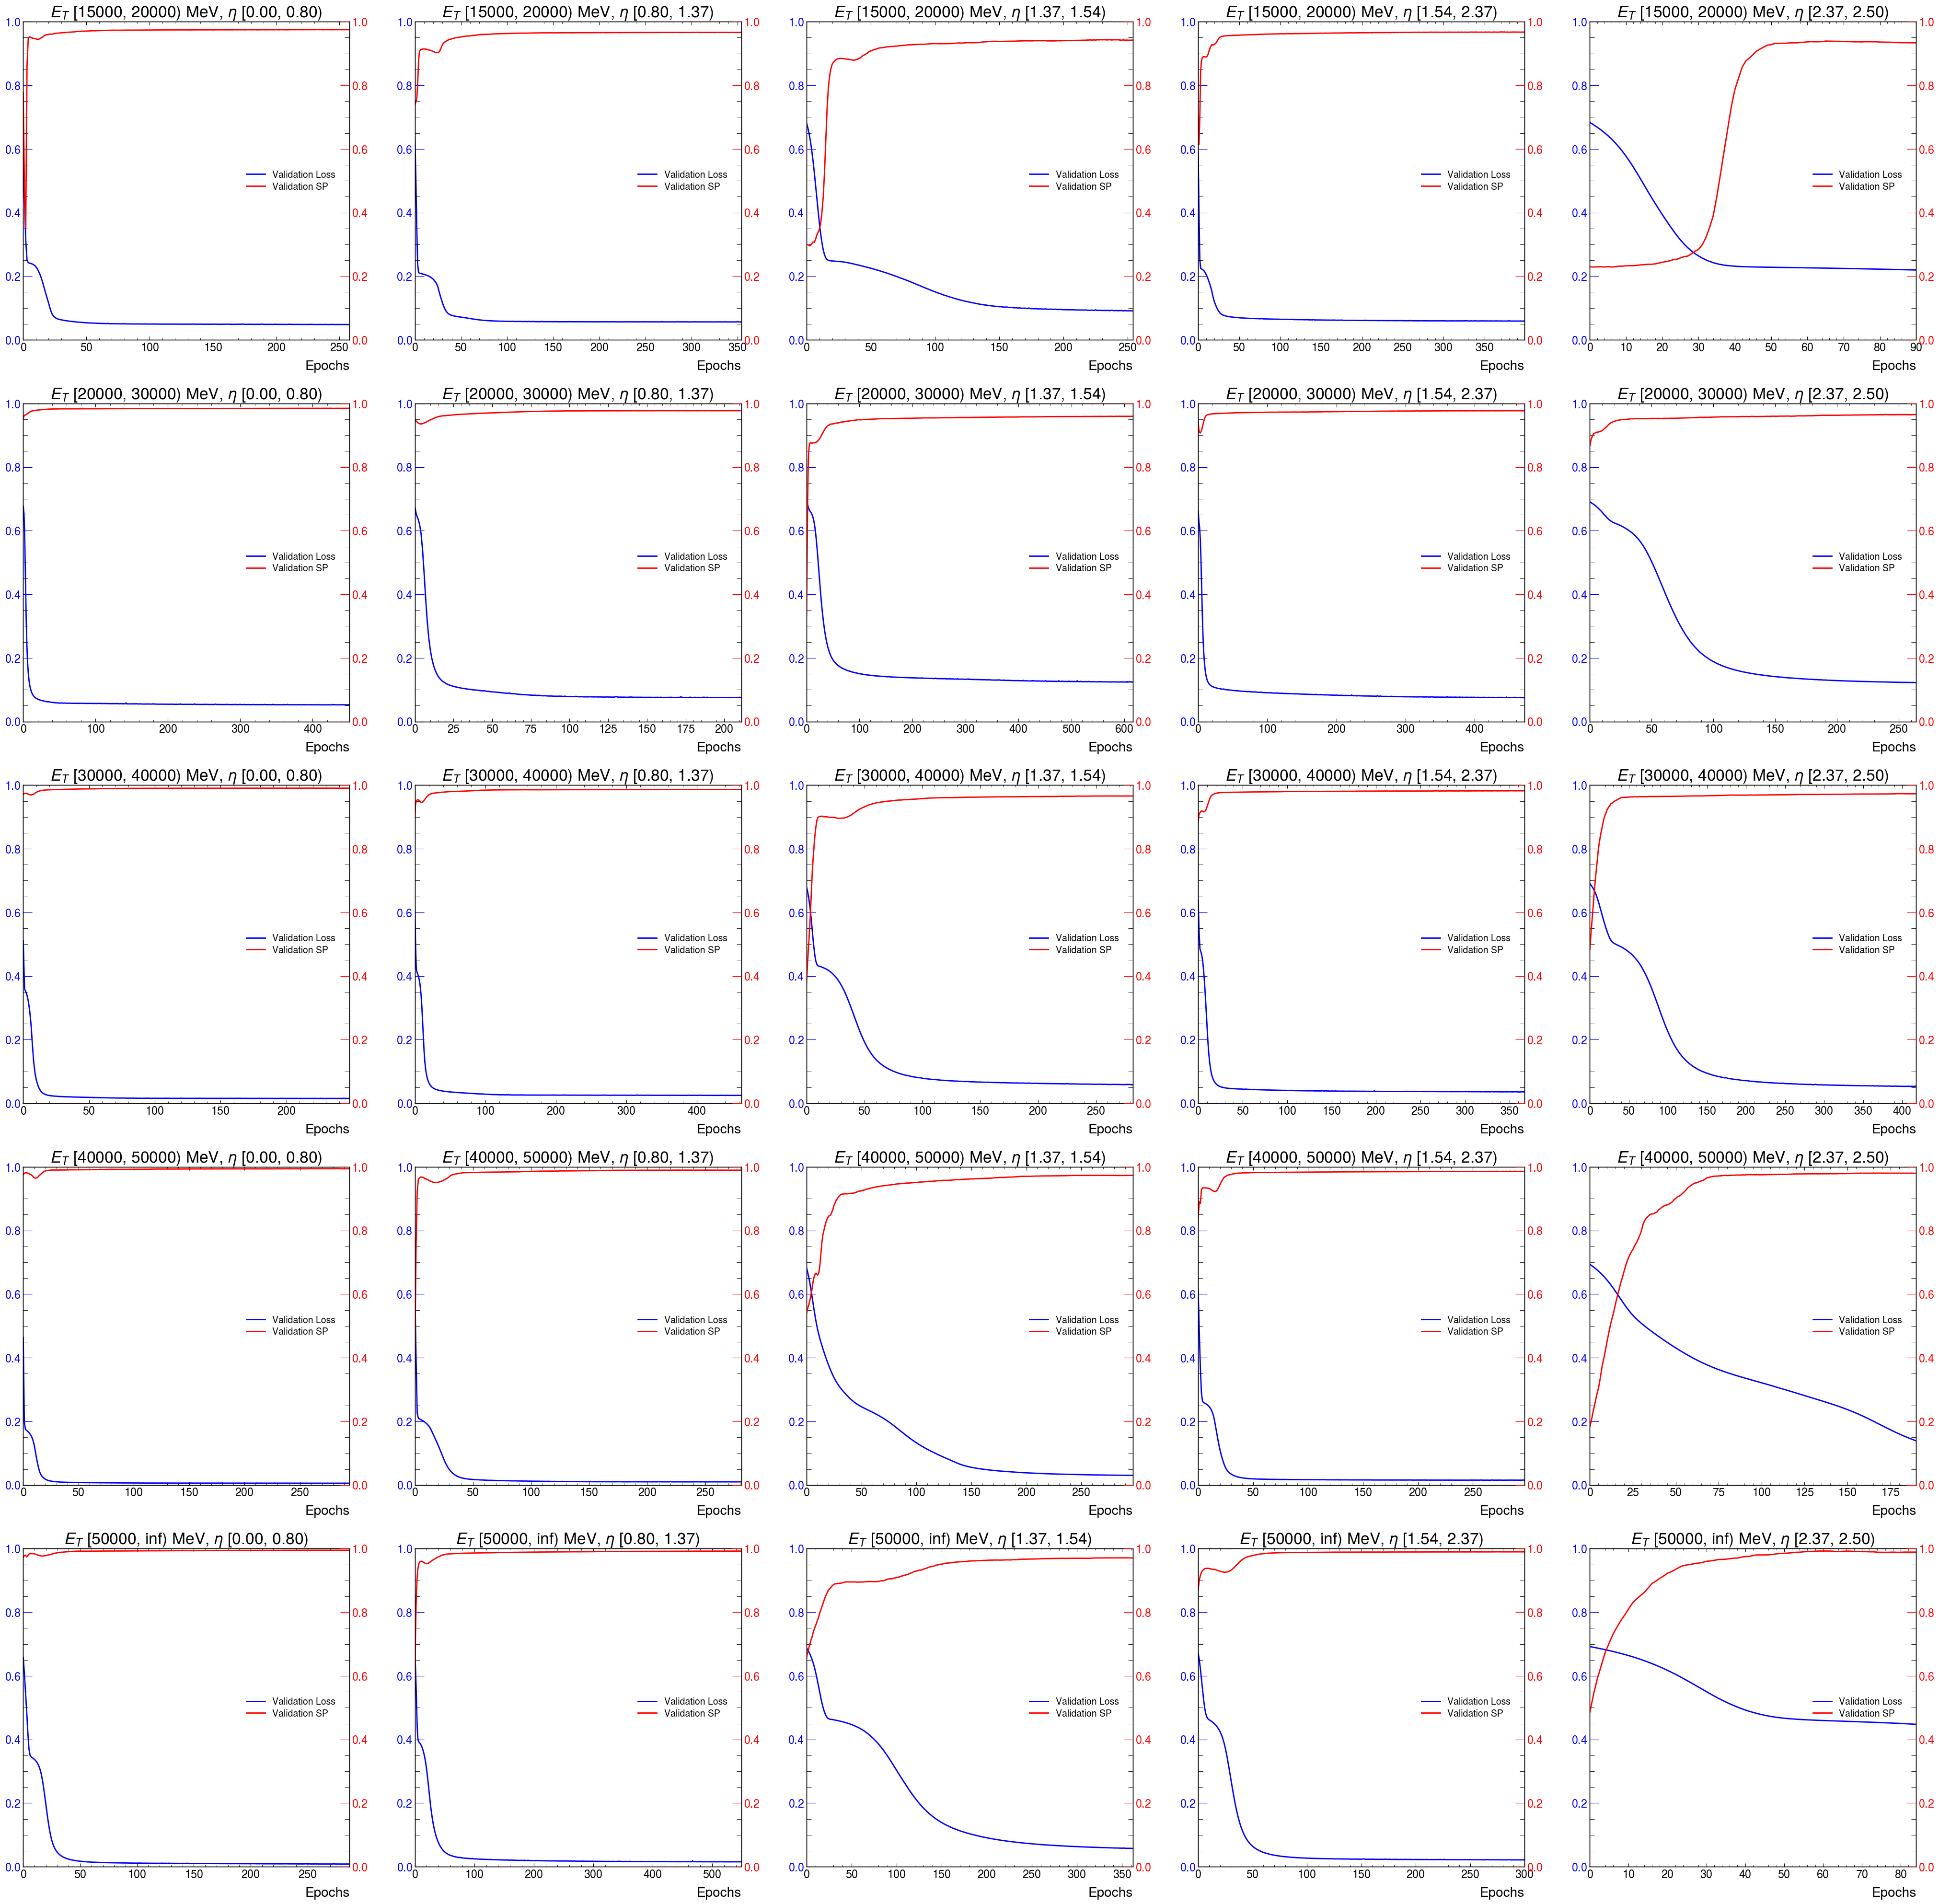

In [3]:
best_models = select_models(model_path)

fig, ax = plt.subplots(int(np.sqrt(len(best_models))),
                       int(np.sqrt(len(best_models))),
                       figsize=(50, 50))

for i, model in enumerate(best_models):
    with open(model["model_dir"] / "results.pic", "rb") as f:
        d = pickle.load(f)

        epochs = range(d["history"]["epochs"])
        loss_data = d["history"]["val_loss"]
        sp_data = d["history"]["val_sp"]
        et_text = f"$E_T$ [{float(d['metadata']['et_bin'][0]):.0f}, {float(d['metadata']['et_bin'][1]):.0f}) MeV"
        eta_symbol = r"$\eta$"
        eta_text = f"{eta_symbol} [{float(d['metadata']['eta_bin'][0]):.2f}, {float(d['metadata']['eta_bin'][1]):.2f})"

        ax1 = ax.flatten()[i]
        lns1 = ax1.plot(epochs, loss_data, "b-", label="Validation Loss")
        ax1.set_xlabel("Epochs")
        ax1.tick_params("y", colors="b")
        ax1.set_xlim(0, epochs[-1])
        ax1.set_ylim(0.0, 1.0)

        ax2 = ax1.twinx()
        lns2 = ax2.plot(epochs, sp_data, "r-", label="Validation SP")
        ax2.tick_params("y", colors="r")
        ax2.set_ylim(0.0, 1.0)

        lns = lns1 + lns2
        labels = [l.get_label() for l in lns]
        ax1.legend(lns, labels, loc="center right")
        ax1.set_title(f"{et_text}, {eta_text}")

plt.show()

In [4]:
model_df = model_inference(
    model_path,
    dataset_dir,
    data_table=DATA_TABLE,
    kfold_table=KFOLD_TABLE,
    et_col=ET_COL,
    eta_col=ETA_COL,
    rings_col=RINGS_COL,
    label_col=LABEL_COL,
    fold_col=FOLD_COL,
    device="cuda",
)

model_df.head()

100%|██████████| 25/25 [01:25<00:00,  3.41s/it]


,id,output,logits,fold,et_bin_left,et_bin_right,eta_bin_left,eta_bin_right
0,1050645,0.000044,-10.021187,4,15000.0,20000.0,0.0,0.8
1,1131992,0.000062,-9.690708,4,15000.0,20000.0,0.0,0.8
2,1181046,0.000040,-10.134415,4,15000.0,20000.0,0.0,0.8
3,1222106,0.000356,-7.941149,4,15000.0,20000.0,0.0,0.8
4,1260450,0.000012,-11.361602,4,15000.0,20000.0,0.0,0.8


In [5]:
data_df = pd.read_parquet(
    dataset_dir / "electron_ringer.parquet", columns=["id", "EventInfoContainer.avgmu", ET_COL, ETA_COL]
)
fold_df = pd.read_parquet(
    dataset_dir / "standard_binning_kfold.parquet", columns=["id", FOLD_COL, LABEL_COL]
)
merged_df = pd.merge(model_df, data_df, on="id")
merged_df = pd.merge(merged_df, fold_df, on="id")

merged_df.head()

,id,output,logits,fold,et_bin_left,et_bin_right,eta_bin_left,eta_bin_right,EventInfoContainer.avgmu,TrigEMClusterContainer.et,TrigEMClusterContainer.eta,kfold,label
0,1050645,0.000044,-10.021187,4,15000.0,20000.0,0.0,0.8,52.499996,17234.820312,0.201381,4,False
1,1131992,0.000062,-9.690708,4,15000.0,20000.0,0.0,0.8,50.500000,16250.170898,-0.053208,4,False
2,1181046,0.000040,-10.134415,4,15000.0,20000.0,0.0,0.8,44.500000,18353.884766,-0.212875,4,False
3,1222106,0.000356,-7.941149,4,15000.0,20000.0,0.0,0.8,48.500000,18047.980469,-0.733716,4,False
4,1260450,0.000012,-11.361602,4,15000.0,20000.0,0.0,0.8,56.500000,18194.527344,0.451560,4,False


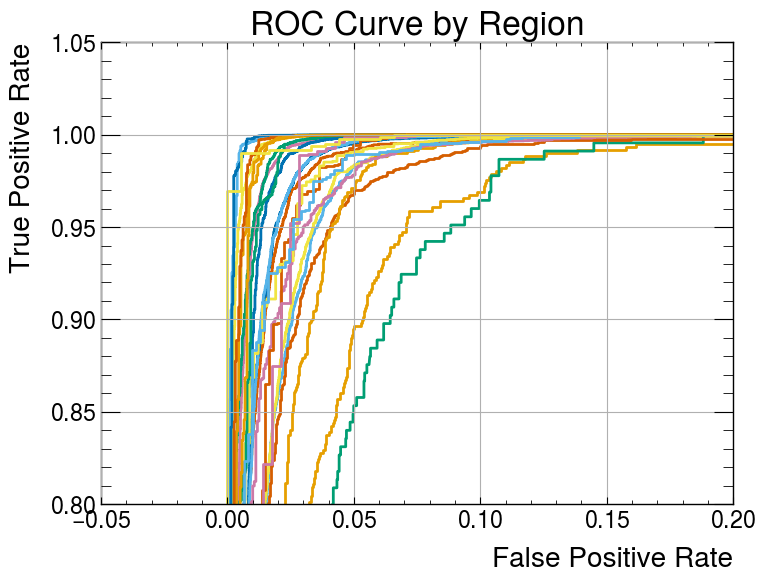

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

fprs = []
tprs = []

for et_left, et_right in zip(merged_df["et_bin_left"].unique(), merged_df["et_bin_right"].unique()):
    for eta_left, eta_right in zip(merged_df["eta_bin_left"].unique(), merged_df["eta_bin_right"].unique()):
        subset = merged_df[
            (merged_df["et_bin_left"] == et_left)
            & (merged_df["et_bin_right"] == et_right)
            & (merged_df["eta_bin_left"] == eta_left)
            & (merged_df["eta_bin_right"] == eta_right)
        ]
        fpr, tpr, _ = roc_curve(subset[LABEL_COL], subset["output"])
        ax.plot(fpr, tpr, label=f"ET: [{et_left}, {et_right}), ETA: [{eta_left}, {eta_right})")
        fprs.append(fpr)
        tprs.append(tpr)

ax.set_xlim([-.05, .2])
ax.set_ylim([.8, 1.05])
ax.grid()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve by Region")
# ax.legend()
plt.show()

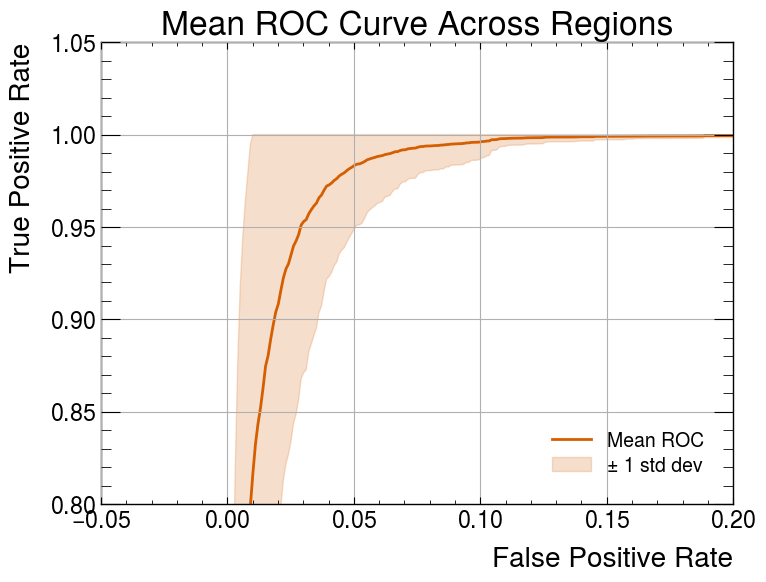

In [7]:
mean_fpr_grid = np.linspace(0.0, 0.2, 200)
interp_tprs = []

for fpr, tpr in zip(fprs, tprs):
    interp_tpr = np.interp(mean_fpr_grid, fpr, tpr, left=np.nan, right=np.nan)
    interp_tprs.append(interp_tpr)

interp_tprs = np.asarray(interp_tprs, dtype=float)
mean_tpr = np.nanmean(interp_tprs, axis=0)
std_tpr = np.nanstd(interp_tprs, axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_fpr_grid, mean_tpr, color="C0", label="Mean ROC")
ax.fill_between(
    mean_fpr_grid,
    np.clip(mean_tpr - std_tpr, 0.0, 1.0),
    np.clip(mean_tpr + std_tpr, 0.0, 1.0),
    color="C0",
    alpha=0.2,
    label="± 1 std dev",
)

ax.set_xlim([-.05, .2])
ax.set_ylim([.8, 1.05])
ax.grid()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Mean ROC Curve Across Regions")
ax.legend()
plt.show()

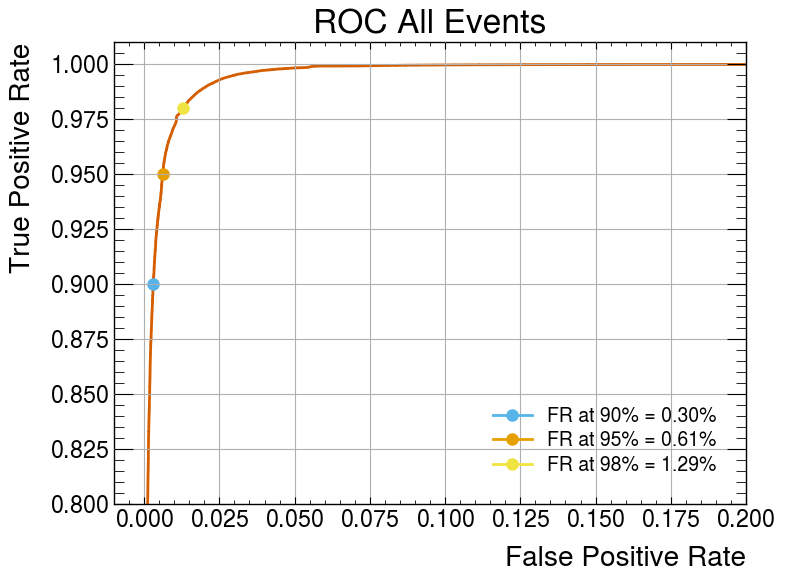

In [8]:
fpr, tpr, thresholds = roc_curve(merged_df["label"], merged_df["output"])
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC All Events")

ax.set_xlim(-0.01, 0.2)
ax.set_ylim(0.8, 1.01)

tpr_thresholds = [0.9, 0.95, 0.98]
for tpr_threshold in tpr_thresholds:
    idx = np.argmin(np.abs(tpr - tpr_threshold))
    ax.plot(
        fpr[idx],
        tpr[idx],
        marker="o",
        label=f"FR at {tpr_threshold:.0%} = {fpr[idx]:.2%}",
    )
ax.legend()

ax.grid()
plt.show()